In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import torch
import os
import pandas as pd
import random

import torchvision.transforms as T
from torch import nn
from torch.utils.data import DataLoader
from tqdm import tqdm
import os
import json
import math
import pickle
import matplotlib.pyplot as plt
from IPython.display import clear_output
from scipy.ndimage import gaussian_filter
from matplotlib.gridspec import GridSpec

from matplotlib.patches import Rectangle

from bioplnn.models import SpatiallyEmbeddedClassifier, SpatiallyEmbeddedAreaConfig, SpatiallyEmbeddedRNN, Ablation
from bioplnn.datasets import Mazes
from bioplnn.utils import (
    initialize_dataloader,
)

maze_data_path = "./data/mazes/"
checkpoint_path = "./train/checkpoints/"

# Torch setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_float32_matmul_precision("high")

batch_size = 64
train_loader, test_loader = initialize_dataloader(
    seed=42, root=maze_data_path, batch_size=batch_size, dataset="mazes"
)
inputs, labels = next(iter(test_loader))

In [3]:
def prepare_rnn_weights(state_dict):
    """Remove 'rnn.' prefix from all keys in the state dict.
        Also remove any key starting with readout"""
    new_state_dict = {}
    for key, value in state_dict.items():
        if key.startswith('rnn.'):
            new_key = key[4:]  # Remove 'rnn.' prefix
            new_state_dict[new_key] = value
        elif not key.startswith('readout'):
            new_state_dict[key] = value
    return new_state_dict
    
def load_model_and_config(wandb_name, checkpoint_path):
    """Load model configuration and instantiate models."""
    try:
        full_cfg = pickle.load(open(checkpoint_path + f"{wandb_name}.pkl", "rb"))
        model_cfg, num_steps = full_cfg["model_config"], full_cfg["num_steps"]
    except:
        model_cfg = pickle.load(open(checkpoint_path + f"{wandb_name}.pkl", "rb"))
        num_steps = 20

    model = SpatiallyEmbeddedRNN(**model_cfg["rnn_kwargs"])
    classifier = SpatiallyEmbeddedClassifier(**model_cfg)
    mazes = Mazes(maze_data_path)
    
    return model, classifier, mazes, num_steps

import numpy as np
from collections import deque


def compute_wall_mask(maze):
    """
    maze: 2D np.array of shape (48,48), 1=corridor, 0=wall
    returns: same shape, dtype=uint8
    """
    return (maze == 1).astype(np.uint8)

def compute_distance_map(maze, start_goal):
    """
    maze: 2D array 1=corridor, 0=wall
    start_goal: 2D binary array, 1 at the two points, 0 elsewhere
    returns: 2D int array where each cell = shortest-path distance (in steps)
             to the nearest start/goal; walls get a large value or np.inf.
    """
    H, W = maze.shape
    dist = np.full((H, W), np.inf, dtype=float)
    q = deque()

    # initialize BFS frontier at both points
    for (i, j), val in np.ndenumerate(start_goal):
        if val == 1:
            dist[i, j] = 0
            q.append((i, j))

    # 4‐connected neighbors
    neighbors = [(1,0),(-1,0),(0,1),(0,-1)]

    while q:
        i, j = q.popleft()
        for di, dj in neighbors:
            ii, jj = i + di, j + dj
            if 0 <= ii < H and 0 <= jj < W:
                # only traverse corridors
                if maze[ii, jj] == 1 and dist[ii, jj] == np.inf:
                    dist[ii, jj] = dist[i, j] + 1
                    q.append((ii, jj))
    return dist

def map_distances(maze, start_goal, radius=2):
    H, W = maze.shape
    dist = np.full((H, W), np.inf, dtype=float)
    maze2 = maze.copy()
    q = deque()

    # seed from input blocks
    for (i,j), v in np.ndenumerate(start_goal):
        if v:
            dist[i,j] = 0
            maze2[i,j] = 1
            q.append((i,j))

    # all offsets in a (2*radius+1)^2 patch, excluding (0,0)
    nbrs = [(dx,dy)
            for dx in range(-radius, radius+1)
            for dy in range(-radius, radius+1)
            if not (dx==0 and dy==0)]

    while q:
        i, j = q.popleft()
        dnext = dist[i, j] + 1
        for dx, dy in nbrs:
            ii, jj = i + dx, j + dy
            if not (0 <= ii < H and 0 <= jj < W): 
                continue
            if maze2[ii, jj] != 1:
                continue

            # only block if both orthogonal neighbors are walls
            if dx != 0 and dy != 0:
                if maze2[i+dx, j] == 0 and maze2[i, j+dy] == 0:
                    continue

            if dist[ii, jj] == np.inf:
                dist[ii, jj] = dnext
                q.append((ii, jj))

    return dist

def bfs_distance(maze, seeds):
    H, W = maze.shape
    dist = np.full((H, W), np.inf, dtype=float)
    q = deque()

    # allow BFS to traverse the seeds even if maze[...] == 0
    maze2 = maze.copy()
    for (i, j) in seeds:
        dist[i, j] = 0
        maze2[i, j] = 1
        q.append((i, j))

    nbrs = [(1,0),(-1,0),(0,1),(0,-1)]
    while q:
        i, j = q.popleft()
        for di, dj in nbrs:
            ii, jj = i+di, j+dj
            if 0 <= ii < H and 0 <= jj < W:
                if maze2[ii, jj] == 1 and dist[ii, jj] == np.inf:
                    dist[ii, jj] = dist[i, j] + 1
                    q.append((ii, jj))
    return dist

def get_start_coordinates(maze, start_goal):
    H, W = maze.shape

    # 1) Flood-fill start_goal into two blocks
    visited = np.zeros_like(start_goal, bool)
    blocks = []
    for (i,j), v in np.ndenumerate(start_goal):
        if v and not visited[i,j]:
            comp, q = [], deque([(i,j)])
            visited[i,j] = True
            while q:
                x,y = q.popleft()
                comp.append((x,y))
                for dx,dy in [(1,0),(-1,0),(0,1),(0,-1)]:
                    nx, ny = x+dx, y+dy
                    if (0<=nx<H and 0<=ny<W and start_goal[nx,ny]
                        and not visited[nx,ny]):
                        visited[nx,ny] = True
                        q.append((nx,ny))
            blocks.append(comp)
    
    return blocks

def compute_shortest_path_mask(maze, start_goal):
    """
    Returns an (H,W) uint8 mask marking corridor cells on any shortest path
    between the two 2×2 input blocks. If the blocks are disconnected, returns
    all zeros.
    """
    H, W = maze.shape

    blocks = get_start_coordinates(maze, start_goal)
    
    if len(blocks) != 2:
        raise ValueError("Expected exactly two disjoint 2×2 blocks in start_goal.")

    # 2) BFS distances from each block
    dist0 = bfs_distance(maze, blocks[0])
    dist1 = bfs_distance(maze, blocks[1])

    # 3) Minimal distance between blocks
    d_min = min(dist0[i,j] for (i,j) in blocks[1])

    # 4) If infinite, no path exists → return zero mask
    if np.isinf(d_min):
        return np.zeros((H, W), dtype=np.uint8)

    # 5) Mark cells where dist0 + dist1 == d_min and are corridors
    sp = ((dist0 + dist1) == d_min) & (maze == 1)
    return sp.astype(np.uint8)


def compute_reachable_mask(dist_map, t):
    """
    All cells reachable within t conv‐hops.
    """
    return (dist_map <= t).astype(np.uint8)

def compute_frontier_shell(dist_map, t):
    """
    Cells reached *exactly* on hop t.
    """
    return (dist_map == t).astype(np.uint8)

def compute_articulation_points(maze, start_goal):
    """
    Binary map of corridor‐cells whose removal disconnects the two input blocks.
    Brute‐force: for each corridor cell, zero it out and test connectivity.
    """
    H, W = maze.shape
    # find the two blocks again
    visited = np.zeros_like(start_goal, bool)
    blocks = []
    for (i,j), v in np.ndenumerate(start_goal):
        if v and not visited[i,j]:
            comp = []
            q = deque([(i,j)])
            visited[i,j] = True
            while q:
                x,y = q.popleft()
                comp.append((x,y))
                for dx,dy in [(1,0),(-1,0),(0,1),(0,-1)]:
                    nx, ny = x+dx, y+dy
                    if 0<=nx<H and 0<=ny<W and start_goal[nx,ny] and not visited[nx,ny]:
                        visited[nx,ny] = True
                        q.append((nx,ny))
            blocks.append(comp)
    assert len(blocks)==2

    def connected_without(rem_i, rem_j):
        """Test if block0 can reach block1 when (rem_i,rem_j) is treated as wall."""
        seen = np.zeros((H,W), bool)
        q = deque()
        # seed from block0, but skip if removing that cell
        for (i,j) in blocks[0]:
            if (i,j)!=(rem_i,rem_j):
                seen[i,j] = True
                q.append((i,j))
        while q:
            i,j = q.popleft()
            if (i,j) in blocks[1]:
                return True
            for di,dj in [(1,0),(-1,0),(0,1),(0,-1)]:
                ii,jj = i+di, j+dj
                if 0<=ii<H and 0<=jj<W and not seen[ii,jj]:
                    if (ii,jj)==(rem_i,rem_j):
                        continue
                    if maze[ii,jj]==1 or start_goal[ii,jj]:
                        seen[ii,jj] = True
                        q.append((ii,jj))
        return False

    art_map = np.zeros((H,W), np.uint8)
    for (i,j), v in np.ndenumerate(maze):
        if v==1 and not start_goal[i,j]:
            if not connected_without(i,j):
                art_map[i,j] = 1
    return art_map

def compute_node_degree(maze):
    """
    For each corridor cell, count 4‐connected corridor neighbors.
    """
    H, W = maze.shape
    deg = np.zeros((H,W), int)
    for (i,j), v in np.ndenumerate(maze):
        if v==1:
            cnt = 0
            for di,dj in [(1,0),(-1,0),(0,1),(0,-1)]:
                ii, jj = i+di, j+dj
                if 0<=ii<H and 0<=jj<W and maze[ii,jj]==1:
                    cnt += 1
            deg[i,j] = cnt
    return deg

def bresenham_line(x0, y0, x1, y1):
    """
    Bresenham’s line algorithm between two integer points (x0,y0)->(x1,y1).
    Returns list of (x,y) coordinates on the line.
    """
    pts = []
    dx = abs(x1-x0)
    dy = abs(y1-y0)
    x, y = x0, y0
    sx = 1 if x1>x0 else -1
    sy = 1 if y1>y0 else -1
    if dx > dy:
        err = dx/2.0
        while x != x1:
            pts.append((x,y))
            err -= dy
            if err < 0:
                y += sy
                err += dx
            x += sx
    else:
        err = dy/2.0
        while y != y1:
            pts.append((x,y))
            err -= dx
            if err < 0:
                x += sx
                err += dy
            y += sy
    pts.append((x1,y1))
    return pts

def compute_euclidean_los_mask(maze, start_goal):
    """
    Binary mask: for each corridor cell (i,j), 1 if there exists at least one
    straight (Bresenham) line to any input cell that passes only through
    corridors or input cells.
    """
    H, W = maze.shape
    los = np.zeros((H,W), np.uint8)
    # list all target coords
    targets = [(i,j) for (i,j),v in np.ndenumerate(start_goal) if v]
    for (i,j), v in np.ndenumerate(maze):
        if v != 1:
            continue
        for (ti,tj) in targets:
            line = bresenham_line(i,j, ti,tj)
            if all(maze[x,y]==1 or start_goal[x,y]==1 for (x,y) in line):
                los[i,j] = 1
                break
    return los

def both_reachable_mask(maze, start_goal, t):
    """
    Return a mask where cells are True iff reachable within ≤ t steps
    from both start1 and start2 using the existing reachable_mask.
    """
    start_coordinates = get_start_coordinates(maze, start_goal)
    
    start1 = np.zeros_like(start_goal)
    for row, col in start_coordinates[0]:
        start1[row,col] = 1

    start2 = np.zeros_like(start_goal)
    try:
        for row, col in start_coordinates[1]:
            start2[row,col] = 1
    except:
        for row, col in start_coordinates[0]:
            start2[row,col] = 1

    dist_map = map_distances(maze, start1)
    reach_start1 = compute_reachable_mask(dist_map, t=t)

    dist_map = map_distances(maze, start2)
    reach_start2 = compute_reachable_mask(dist_map, t=t)

    return reach_start1 & reach_start2

In [29]:
# ——— User‐set paths & names ———
# wandb_name    = "twilight-spaceship-341"
# checkpoint    = 390    # also used as epoch

# ReLU
wandb_name = "earnest-planet-436"
checkpoint = 800

# ReLU, I->I recurrence, Center-Excitation
wandb_name = "young-totem-460"
checkpoint = 480

# ——— Load model config & instantiate ———
model, classifier, mazes, num_steps = load_model_and_config(wandb_name, checkpoint_path)
model.to(device)

# ——— Load checkpoint & weights ———
try:
    state_dict = torch.load(checkpoint_path + f"{wandb_name}_{checkpoint}.pth", map_location=torch.device('cpu'))
except:
    state_dict = torch.load(checkpoint_path + f"{wandb_name}/{checkpoint}.pth", map_location=torch.device('cpu'))

try:
    state_dict = state_dict["model_state"]
except:
    pass

model.load_state_dict(prepare_rnn_weights(state_dict))

/tmp/ipykernel_339534/4045812314.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkpoint_path + f"{wandb_name}_{checkpoint}.pth", map_locatio

<All keys matched successfully>

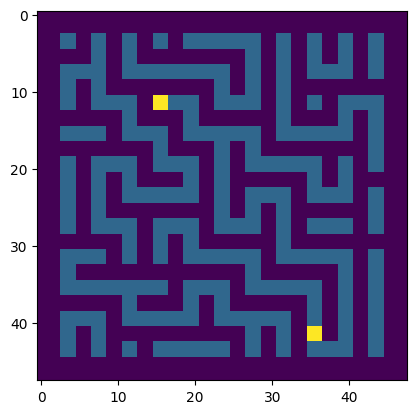

In [173]:
sample_idx = 11
plt.imshow(inputs[sample_idx, 0] + inputs[sample_idx, -1]*2)
plt.show()

In [181]:
# maze and start_goal both (48,48) arrays:
maze = np.array(inputs[sample_idx, 0])
start_goal = np.array(inputs[sample_idx, -1])
print(maze.shape)
print(start_goal.shape)

dist_map = map_distances(maze, start_goal)
reach_map = compute_reachable_mask(dist_map, t=3)  
both_reachable = both_reachable_mask(maze, start_goal, t=8)
sp_mask = compute_shortest_path_mask(maze, start_goal)
shell3   = compute_frontier_shell(dist_map, t=3)
deg_map  = compute_node_degree(maze)
los_map  = compute_euclidean_los_mask(maze, start_goal)

# print("Shapes:", sp_mask.shape, shell3.shape, art_map.shape, deg_map.shape, los_map.shape)

(48, 48)
(48, 48)


/tmp/ipykernel_3468787/3742002940.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  maze = np.array(inputs[sample_idx, 0])
/tmp/ipykernel_3468787/3742002940.py:3: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  start_goal = np.array(inputs[sample_idx, -1])


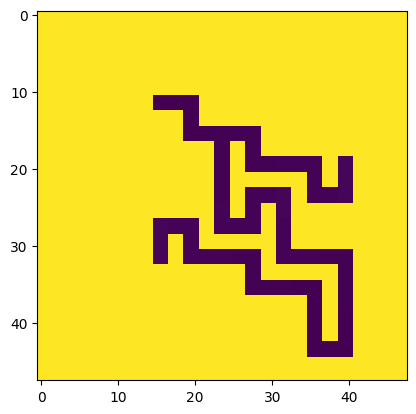

In [145]:
plt.imshow(dist_matrix[sample_idx].reshape(48, 48))

/tmp/ipykernel_3468787/729844617.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.imshow(inputs[sample_idx, 0] + compute_reachable_mask(dist_map, t=8)*2 + inputs[sample_idx, -1]*4)


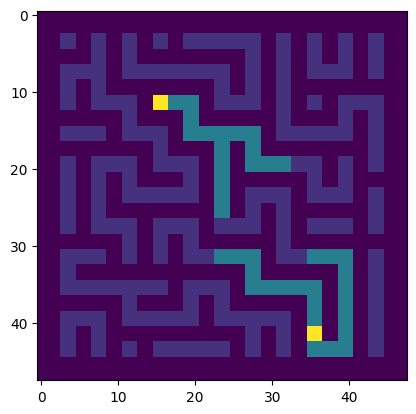

/tmp/ipykernel_3468787/729844617.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.imshow(inputs[sample_idx, 0] + dist_map*2 + inputs[sample_idx, -1]*4)


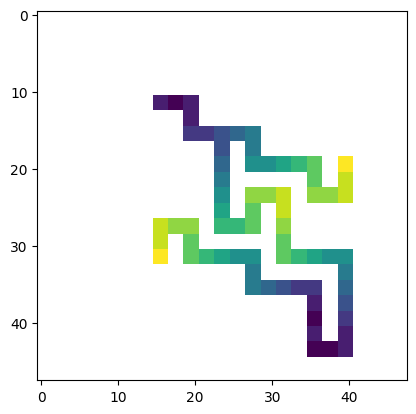

/tmp/ipykernel_3468787/729844617.py:7: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.imshow(inputs[sample_idx, 0] + both_reachable_mask(maze, start_goal, t=12)*2 + inputs[sample_idx, -1]*4)


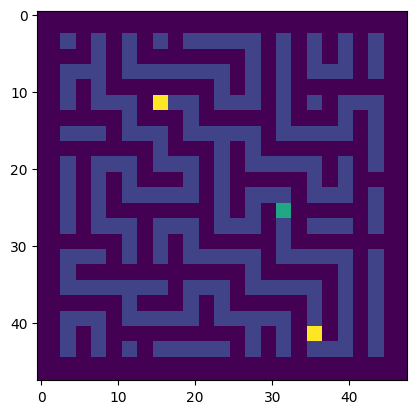

In [180]:
plt.imshow(inputs[sample_idx, 0] + compute_reachable_mask(dist_map, t=8)*2 + inputs[sample_idx, -1]*4)
plt.show()

plt.imshow(inputs[sample_idx, 0] + dist_map*2 + inputs[sample_idx, -1]*4)
plt.show()

plt.imshow(inputs[sample_idx, 0] + both_reachable_mask(maze, start_goal, t=12)*2 + inputs[sample_idx, -1]*4)
plt.show()

In [5]:
import numpy as np
from scipy.special import digamma
from sklearn.neighbors import KDTree
from joblib import Parallel, delayed
from tqdm.notebook import tqdm  # or: from tqdm.auto import tqdm

# 1-D KL entropy for continuous y (nats)
def _kl_entropy_1d(y, k=5):
    y = np.asarray(y, float).reshape(-1, 1)
    N = y.shape[0]
    if N <= k: return np.nan
    tree = KDTree(y, metric='euclidean')
    dists, _ = tree.query(y, k=k+1)       # includes self
    r = dists[:, k]
    # Unit-ball volume in 1D (L2) is 2
    return digamma(N) - digamma(k) + np.log(2.0) + (1.0/N)*np.sum(np.log(r + 1e-12))

# Mixed MI for general discrete A and continuous y
def _mi_mixed_discrete_continuous(a_disc, y, k=5, min_count=3):
    a = np.asarray(a_disc)
    y = np.asarray(y, float)
    N = len(a)
    # If A is constant in this bootstrap: MI = 0
    if np.unique(a).size == 1:
        return 0.0
    # H(B)
    k_full = min(k, N-1)
    h_y = _kl_entropy_1d(y, k=k_full)

    # Sum p(a) H(B|A=a)
    vals, counts = np.unique(a, return_counts=True)
    cond = 0.0
    for v, n_v in zip(vals, counts):
        if n_v < max(min_count, 2):
            return np.nan  # too few samples for a reliable conditional entropy
        k_v = min(k, n_v-1)
        h_y_v = _kl_entropy_1d(y[a == v], k=k_v)
        cond += (n_v / N) * h_y_v
    return h_y - cond

def neuronwise_mi_mixed_bootstrap_parallel(
    A, B, k=5, max_samples=20000, n_bootstraps=3,
    var_thresh=1e-8, min_count=3, n_jobs=-1, random_state=0,
    show_progress=True, return_stderr=True, return_mask=False,
    chunk_size=64,
):
    """
    Per-neuron MI with mixed estimator (discrete A_j, continuous B_j),
    using subsampling, parallelization, and robust progress bars.
    Skips neurons if B variance is tiny OR if any class in A_j has < min_count
    in a bootstrap (that bootstrap returns NaN for that neuron).
    """
    rng = np.random.default_rng(random_state)
    A = np.asarray(A)             # A_j can be ints/labels; will be compared with ==
    B = np.asarray(B, float)
    assert A.shape == B.shape
    N, D = A.shape

    # Static mask on A variance (computed on full data)
    mask = (A.var(axis=0) >= var_thresh)
    valid_idx = np.where(mask)[0]

    bs = min(max_samples, N)
    mi_accum = np.full((n_bootstraps, D), np.nan, float)

    for b in range(n_bootstraps):
        idx = rng.choice(N, size=bs, replace=False)
        As = A[idx]; Bs = B[idx]

        def _worker(j):
            # indices = np.where(~np.isinf(As[:, j]))[0]
            return _mi_mixed_discrete_continuous(As[:, j], Bs[:, j], k=k, min_count=min_count)

        out = np.empty(len(valid_idx), float)
        if show_progress:
            pbar = tqdm(total=len(valid_idx), desc=f"Mixed MI (boot {b+1}/{n_bootstraps})", leave=True)
        for s in range(0, len(valid_idx), chunk_size):
            chunk = valid_idx[s:s+chunk_size]
            res = Parallel(n_jobs=n_jobs, backend="loky", batch_size=1)(
                delayed(_worker)(j) for j in chunk
            )
            out[s:s+len(res)] = res
            if show_progress: pbar.update(len(res))
        if show_progress: pbar.close()

        mi_accum[b, valid_idx] = out

    mi_mean = np.nanmean(mi_accum, axis=0)
    if return_stderr:
        mi_stderr = np.full(D, np.nan, float)
        mi_stderr[valid_idx] = np.nanstd(mi_accum[:, valid_idx], axis=0, ddof=1) / np.sqrt(n_bootstraps)
        return (mi_mean, mi_stderr, mask) if return_mask else (mi_mean, mi_stderr)
    else:
        return (mi_mean, mask) if return_mask else mi_mean


In [30]:
excitatory = True
num_steps = 20

num_samples = len(test_loader.dataset) if hasattr(test_loader, 'dataset') else sum(1 for _ in test_loader)
activations = np.zeros((num_samples, num_steps, 8, 48, 48), dtype=np.float32)

sample_idx = 0
for batch_inputs, label in tqdm(test_loader):
    # input: (batch_size, channels, H, W)
    batch_size = batch_inputs.shape[0]
    batch_inputs = batch_inputs.to(device)
    _, batch_neuron_states, _ = model(batch_inputs, num_steps=num_steps)
    activity = model.query_neuron_states(batch_neuron_states, 0, 0 if excitatory else 1).detach().cpu().numpy()
    activations[sample_idx:sample_idx+batch_size, :, :, :, :] = activity
    sample_idx += batch_size

  0%|          | 0/1080 [00:00<?, ?it/s]

In [6]:
excitatory = True

num_samples = len(test_loader.dataset) if hasattr(test_loader, 'dataset') else sum(1 for _ in test_loader)
output_activations = np.zeros((num_samples, 20, 8, 48, 48), dtype=np.float32)

sample_idx = 0
for batch_inputs, label in tqdm(test_loader):
    # input: (batch_size, channels, H, W)
    batch_size = batch_inputs.shape[0]
    batch_inputs = batch_inputs.to(device)
    output_states, batch_neuron_states, _ = model(batch_inputs, num_steps=num_steps)
    activity = output_states[0][0].detach().cpu()
    output_activations[sample_idx:sample_idx+batch_size, :, :, :, :] = activity
    sample_idx += batch_size

num_channels = output_activations.shape[1]
num_steps = output_activations.shape[2]
num_neurons = output_activations.shape[3]

  0%|          | 0/1080 [00:00<?, ?it/s]

/tmp/ipykernel_3600598/23448794.py:13: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  output_activations[sample_idx:sample_idx+batch_size, :, :, :, :] = activity


In [7]:
num_samples = len(test_loader.dataset) if hasattr(test_loader, 'dataset') else sum(1 for _ in test_loader)

# dist_matrix = np.zeros((num_samples, 48, 48))
# idx = 0
# for batch_inputs, label in tqdm(test_loader):
#     batch_size = batch_inputs.shape[0]
#     for b in range(batch_size):
#         maze = np.array(batch_inputs[b, 0])
#         start_goal = np.array(batch_inputs[b, -1])
#         dist_map = map_distances(maze, start_goal)
#         dist_matrix[idx, :, :] = dist_map
#         idx += 1

# dist_matrix = dist_matrix.reshape(dist_matrix.shape[0], -1)
# dist_matrix = np.where(np.isinf(dist_matrix), 1000, dist_matrix)

# num_samples = len(test_loader.dataset) if hasattr(test_loader, 'dataset') else sum(1 for _ in test_loader)
# los_matrix = np.zeros((num_samples, 48, 48))
# idx = 0
# for batch_inputs, label in tqdm(test_loader):
#     batch_size = batch_inputs.shape[0]
#     for b in range(batch_size):
#         maze = np.array(batch_inputs[b, 0])
#         start_goal = np.array(batch_inputs[b, -1])
#         los_map = compute_euclidean_los_mask(maze, start_goal)
#         los_matrix[idx, :, :] = los_map
#         idx += 1

# los_matrix = los_matrix.reshape(los_matrix.shape[0], -1)
# los_matrix = np.where(np.isinf(los_matrix), 1000, los_matrix)

# frontier_matrix = np.zeros((num_samples, num_steps, 48*48))
# for sample_idx, dist_map in enumerate(dist_matrix):
#     for step_idx in range(num_steps):
#         frontier = compute_frontier_shell(dist_map, t=step_idx)
#         frontier_matrix[sample_idx, step_idx] = frontier

# reachable_matrix = np.zeros((num_samples, num_steps, 48*48))
# for sample_idx, dist_map in enumerate(dist_matrix):
#     for step_idx in range(num_steps):
#         reachable = compute_reachable_mask(dist_map, t=step_idx)
#         reachable_matrix[sample_idx, step_idx] = reachable

# num_steps = 30
# both_reachable_matrix = np.zeros((num_samples, num_steps, 48*48))
# idx = 0
# for batch_inputs, label in tqdm(test_loader):
#     batch_size = batch_inputs.shape[0]
#     for b in range(batch_size):
#         maze = np.array(batch_inputs[b, 0])
#         start_goal = np.array(batch_inputs[b, -1])
#         for step_idx in range(num_steps):
#             reachable = both_reachable_mask(maze, start_goal, t=step_idx+20)
#             both_reachable_matrix[idx, step_idx] = reachable.flatten()
#         idx += 1
# np.save("feature_maps/both_reachable_matrix", both_reachable_matrix)

  0%|          | 0/1080 [00:00<?, ?it/s]

/tmp/ipykernel_2437669/3396690569.py:50: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  maze = np.array(batch_inputs[b, 0])
/tmp/ipykernel_2437669/3396690569.py:51: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  start_goal = np.array(batch_inputs[b, -1])


In [18]:
# dist_matrix = np.load("feature_maps/dist_matrix.npy")
frontier_matrix = np.load("feature_maps/frontier_matrix.npy")
reachable_matrix = np.load("feature_maps/reachable_matrix.npy")
# both_reachable_matrix = np.load("feature_maps/both_reachable_matrix.npy")

In [ ]:
num_channels = activations.shape[2]
num_steps = activations.shape[1]
num_neurons = activations.shape[3]
mi_vectors = np.zeros((num_channels, num_steps, num_neurons))
analysis_steps = [2, 3, 4, 6, 9, 12, 15, 18, 19]
analysis_steps = [3, 6, 9, 12, 15, 19, 21, 23, 25, 27, 29]

for step_idx in analysis_steps:
    for channel_idx in range(num_channels):

        # std = activations[:, channel_idx, step_idx].std().item()
        # mean = activations[:, channel_idx, step_idx].mean().item()
        # shape = activations[:, channel_idx, step_idx].shape
        # random_activations = np.random.randn(*shape) * std + mean

        mi_vector = neuronwise_mi_mixed_bootstrap_parallel(both_reachable_matrix[:, step_idx], activations[:, step_idx, channel_idx], max_samples=5000, n_bootstraps=1, return_stderr=False)
        mi_vectors[channel_idx, step_idx] = mi_vector

In [31]:
num_samples = 5000

steps_start = 0
total_num_steps = num_steps - steps_start

num_channels = activations.shape[2]

A = both_reachable_matrix[:num_samples, steps_start:num_steps].reshape(num_samples*total_num_steps, -1)
flattened_activations = activations[:num_samples, steps_start:num_steps].reshape(num_samples*total_num_steps, num_channels, -1)

num_neurons = flattened_activations.shape[-1]

mi_vectors = np.zeros((num_channels, num_neurons))

for channel_idx in range(num_channels):
    mi_vector = neuronwise_mi_mixed_bootstrap_parallel(A, flattened_activations[:, channel_idx], max_samples=10000, n_bootstraps=1, return_stderr=False)
    mi_vectors[channel_idx] = mi_vector

Mixed MI (boot 1/1):   0%|          | 0/1364 [00:00<?, ?it/s]

/tmp/ipykernel_339534/1148133374.py:88: RuntimeWarning: Mean of empty slice
  mi_mean = np.nanmean(mi_accum, axis=0)


Mixed MI (boot 1/1):   0%|          | 0/1364 [00:00<?, ?it/s]

Mixed MI (boot 1/1):   0%|          | 0/1364 [00:00<?, ?it/s]

Mixed MI (boot 1/1):   0%|          | 0/1364 [00:00<?, ?it/s]

Mixed MI (boot 1/1):   0%|          | 0/1364 [00:00<?, ?it/s]

Mixed MI (boot 1/1):   0%|          | 0/1364 [00:00<?, ?it/s]

Mixed MI (boot 1/1):   0%|          | 0/1364 [00:00<?, ?it/s]

Mixed MI (boot 1/1):   0%|          | 0/1364 [00:00<?, ?it/s]

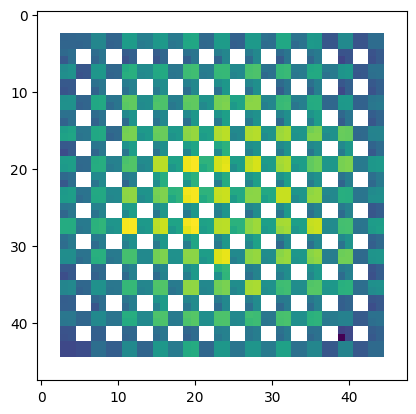

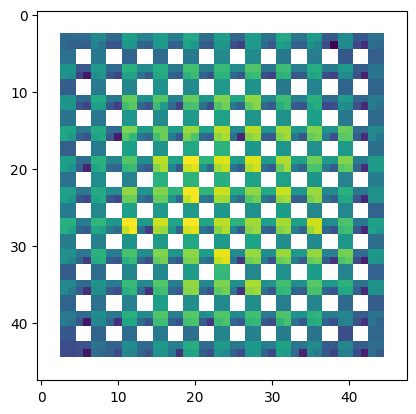

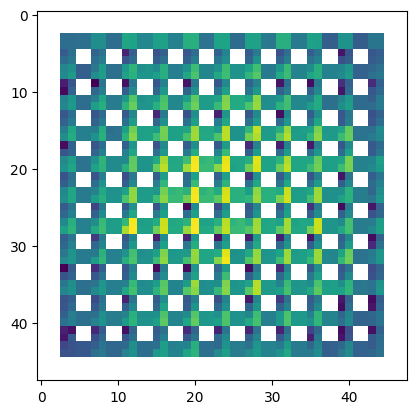

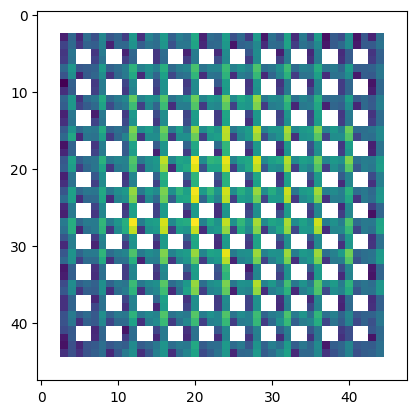

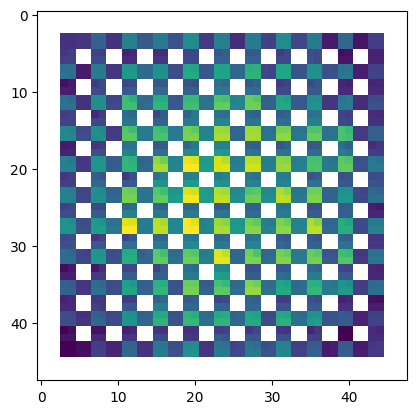

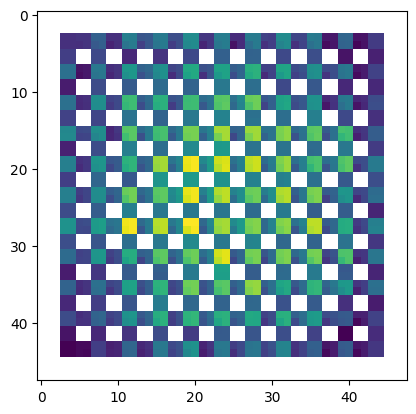

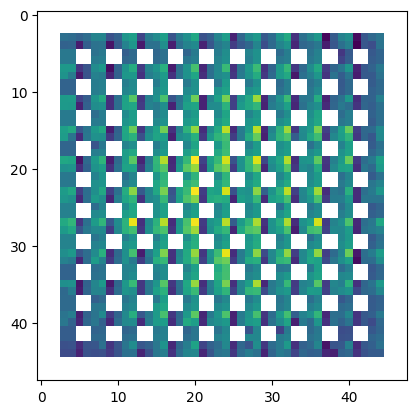

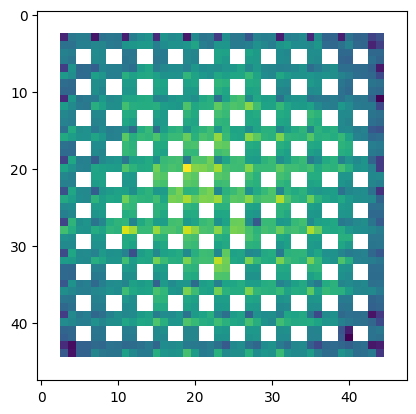

In [22]:
for i in range(8):
    plt.imshow(mi_vectors[i].reshape(48,48))
    plt.show()

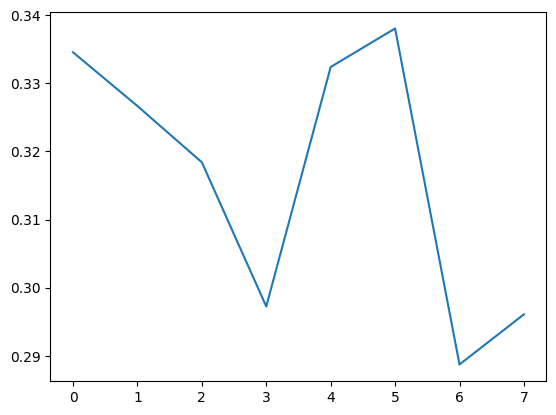

In [27]:
plt.plot(np.nanmean(mi_vectors, axis=1))

In [ ]:
for channel_idx in range(num_channels):
    fig, axs = plt.subplots(2, 3, figsize=(10, 10))
    for ax, step_idx in zip(axs.flatten(), analysis_steps):
        mi_vector = mi_vectors[channel_idx, step_idx]
        mi_vector = mi_vector.reshape(48, 48)
        # mi_vector = np.clip(mi_vector, 0, None)
        im = ax.imshow(mi_vector)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.show()

/tmp/ipykernel_3640402/2837259365.py:14: RuntimeWarning: Mean of empty slice
  mean_mi = np.nanmean(mi_vector_steps, axis=-1)  # shape: (len(analysis_steps),)
/om2/vast/evlab/jackking/anaconda/envs/bioplnn/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


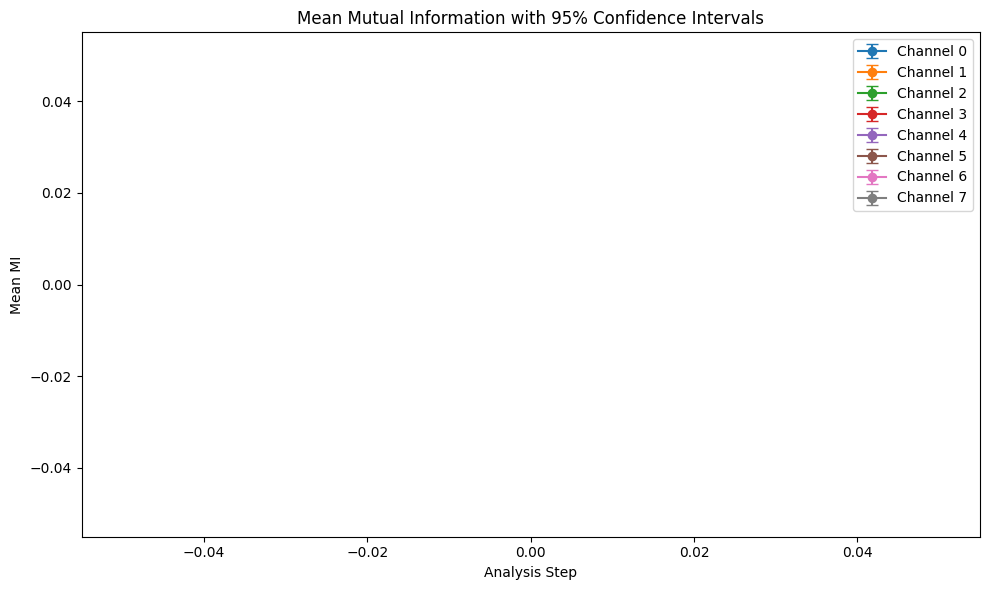

In [9]:
import scipy.stats as stats

plt.figure(figsize=(10, 6))
try:
    from matplotlib import colormaps
    colors = colormaps['tab10'].colors
except (ImportError, AttributeError, KeyError):
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

for channel_idx in range(num_channels):
    mi_vector = np.clip(mi_vectors[channel_idx, :], 0, None)  # shape: (num_steps, num_neurons)
    # Only use analysis_steps
    mi_vector_steps = mi_vector[analysis_steps]  # shape: (len(analysis_steps), num_neurons)
    mean_mi = np.nanmean(mi_vector_steps, axis=-1)  # shape: (len(analysis_steps),)
    std_mi = np.nanstd(mi_vector_steps, axis=-1)    # shape: (len(analysis_steps),)
    n = np.sum(~np.isnan(mi_vector_steps), axis=-1) # number of non-nan samples per step
    # 95% confidence interval: mean ± 1.96 * std / sqrt(n)
    ci95 = 1.96 * std_mi / np.sqrt(n)
    color = colors[channel_idx % len(colors)]
    label = f'Channel {channel_idx}'
    plt.errorbar(analysis_steps, mean_mi, yerr=ci95, fmt='-o', color=color, label=label, capsize=4)
plt.xlabel('Analysis Step')
plt.ylabel('Mean MI')
plt.title('Mean Mutual Information with 95% Confidence Intervals')
plt.legend()
plt.tight_layout()
plt.show()

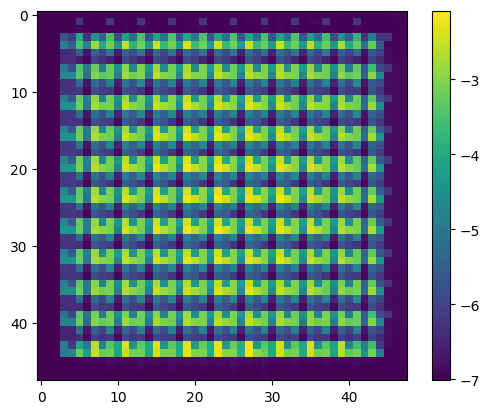

In [22]:
plt.imshow(mi_vector.reshape(48, 48))
plt.colorbar()

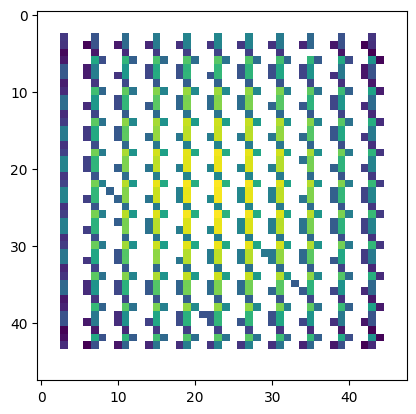

In [13]:
plt.imshow(mi_vector[0].reshape(48, 48))